In [1]:
# ==========================================
# HW1 Personal Parameters
# ==========================================

SID4 = 5996

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6

CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print("SID4 :", SID4)
print("SEED :", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

SID4 : 5996
SEED : 5996
SLICE: 996
HP_ID: 2
CLS_A: 6
CLS_B: 2


### Personal Parameters

- **SID4:** 5996
- **SEED:** 5996
- **SLICE:** 996
- **HP_ID:** 2
- **CLS_A:** 6
- **CLS_B:** 2

For HW1, HP_ID = 2 corresponds to the **Learning-rate-high** experimental arm.

The assigned modified neural-network configuration is:

- Hidden layers: `[64, 32]`
- Learning rate: `0.003`
- Epochs: `30`

The baseline configuration uses the same `[64, 32]` architecture and 30 epochs, but uses a learning rate of `0.001`.

In [2]:
import random
import numpy as np
import torch
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seeds initialized with SEED =", SEED)

Random seeds initialized with SEED = 5996


In [3]:
# Baseline configuration
baseline_hidden = [64, 32]
baseline_lr = 0.001
baseline_epochs = 30

# HP_ID = 2 modified configuration
modified_hidden = [64, 32]
modified_lr = 0.003
modified_epochs = 30

print("Baseline:")
print(" Hidden layers:", baseline_hidden)
print(" Learning rate:", baseline_lr)
print(" Epochs:", baseline_epochs)

print("\nModified model (HP_ID = 2):")
print(" Hidden layers:", modified_hidden)
print(" Learning rate:", modified_lr)
print(" Epochs:", modified_epochs)

Baseline:
 Hidden layers: [64, 32]
 Learning rate: 0.001
 Epochs: 30

Modified model (HP_ID = 2):
 Hidden layers: [64, 32]
 Learning rate: 0.003
 Epochs: 30


In [4]:
training_seeds = [
    SEED,
    SEED + 1,
    SEED + 2
]

print(training_seeds)

[5996, 5997, 5998]


In [5]:
random_state=5996

In [10]:
import pandas as pd

df = pd.read_csv("/content/diabetes.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (758, 9)


,-0.294118,0.487437,0.180328,-0.292929,0,0.00149028,-0.53117,-0.0333333,0.1
0,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
1,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
2,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
3,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0
4,-0.411765,0.165829,0.213115,0.000000,0.000000,-0.236960,-0.894962,-0.700000,1



Column names:
['-0.294118', '0.487437', '0.180328', '-0.292929', '0', '0.00149028', '-0.53117', '-0.0333333', '0.1']


In [7]:
print(df.columns.tolist())

['-0.294118', '0.487437', '0.180328', '-0.292929', '0', '0.00149028', '-0.53117', '-0.0333333', '0.1']


In [8]:
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   -0.294118   758 non-null    float64
 1   0.487437    758 non-null    float64
 2   0.180328    758 non-null    float64
 3   -0.292929   758 non-null    float64
 4   0           758 non-null    float64
 5   0.00149028  758 non-null    float64
 6   -0.53117    758 non-null    float64
 7   -0.0333333  758 non-null    float64
 8   0.1         758 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 53.4 KB

Missing values:
-0.294118     0
0.487437      0
0.180328      0
-0.292929     0
0             0
0.00149028    0
-0.53117      0
-0.0333333    0
0.1           0
dtype: int64

Number of duplicate rows:
0

Summary statistics:


,-0.294118,0.487437,0.180328,-0.292929,0,0.00149028,-0.53117,-0.0333333,0.1
count,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000
mean,-0.407807,0.218208,0.176500,-0.289731,-0.323961,-0.032289,-0.663427,-0.516799,0.654354
std,0.386493,0.306465,0.201420,0.258651,0.375608,0.205508,0.283202,0.400674,0.475893
min,-0.882353,-0.557789,-0.606557,-0.858586,-0.966903,-0.457526,-0.994876,-0.966667,0.000000
25%,-0.764706,-0.005025,0.016393,-0.494949,-0.716312,-0.179583,-0.858241,-0.866667,0.000000
50%,-0.529412,0.165829,0.180328,-0.292929,0.000000,-0.034277,-0.748506,-0.633333,1.000000
75%,0.000000,0.407035,0.311475,0.000000,0.000000,0.087929,-0.532451,-0.233333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/diabetes.csv", header=None)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (759, 9)


,0,1,2,3,4,5,6,7,8
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0



Column names:
[0, 1, 2, 3, 4, 5, 6, 7, 8]


In [12]:
print("Unique values in last column:")
print(df.iloc[:, -1].unique())

print("\nTarget distribution:")
print(df.iloc[:, -1].value_counts())

Unique values in last column:
[0 1]

Target distribution:
8
1    496
0    263
Name: count, dtype: int64


In [13]:
df.columns = [
    "Feature_1",
    "Feature_2",
    "Feature_3",
    "Feature_4",
    "Feature_5",
    "Feature_6",
    "Feature_7",
    "Feature_8",
    "Outcome"
]

display(df.head())

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


In [14]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (759, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  759 non-null    float64
 1   Feature_2  759 non-null    float64
 2   Feature_3  759 non-null    float64
 3   Feature_4  759 non-null    float64
 4   Feature_5  759 non-null    float64
 5   Feature_6  759 non-null    float64
 6   Feature_7  759 non-null    float64
 7   Feature_8  759 non-null    float64
 8   Outcome    759 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 53.5 KB

Missing values:
Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Feature_5    0
Feature_6    0
Feature_7    0
Feature_8    0
Outcome      0
dtype: int64

Duplicate rows:
0

Summary statistics:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Outcome
count,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000
mean,-0.407657,0.218563,0.176505,-0.289735,-0.323534,-0.032245,-0.663253,-0.516162,0.653491
std,0.386260,0.306419,0.201287,0.258480,0.375544,0.205376,0.283056,0.400794,0.476171
min,-0.882353,-0.557789,-0.606557,-0.858586,-0.966903,-0.457526,-0.994876,-0.966667,0.000000
25%,-0.764706,-0.005025,0.016393,-0.494949,-0.716312,-0.178837,-0.858241,-0.866667,0.000000
50%,-0.529412,0.165829,0.180328,-0.292929,0.000000,-0.034277,-0.747225,-0.633333,1.000000
75%,0.000000,0.407035,0.311475,0.000000,0.000000,0.087929,-0.531597,-0.233333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
print("Target counts:")
print(df["Outcome"].value_counts())

print("\nTarget percentages:")
print(
    df["Outcome"].value_counts(normalize=True) * 100
)

Target counts:
Outcome
1    496
0    263
Name: count, dtype: int64

Target percentages:
Outcome
1    65.349144
0    34.650856
Name: proportion, dtype: float64


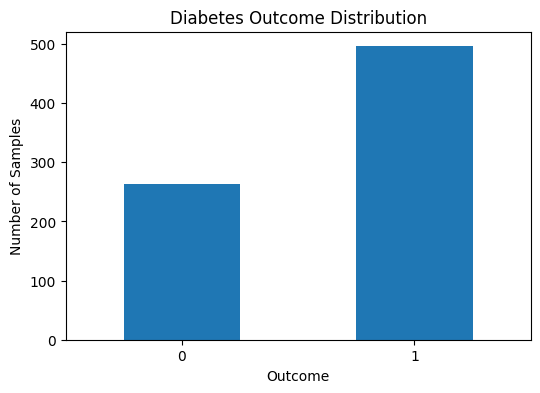

In [16]:
plt.figure(figsize=(6, 4))

df["Outcome"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Outcome")
plt.ylabel("Number of Samples")
plt.title("Diabetes Outcome Distribution")
plt.xticks(rotation=0)

plt.show()

### Target Distribution

The final column of the supplied dataset is the binary target variable,
with classes 0 and 1. I examined the number and percentage of samples
in each class before training the neural networks.

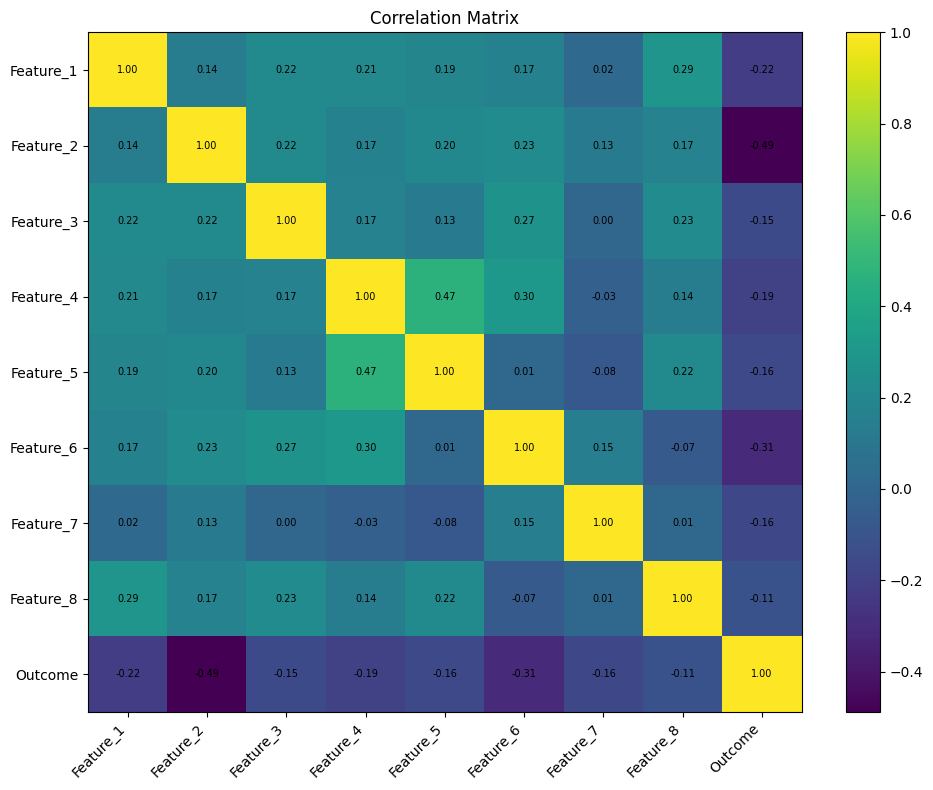

In [17]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlation Matrix

The correlation matrix shows the pairwise linear relationships among
the eight input features and the binary outcome. It was used to inspect
which transformed features have stronger positive or negative
relationships with the target and whether any input features are
strongly correlated with each other.

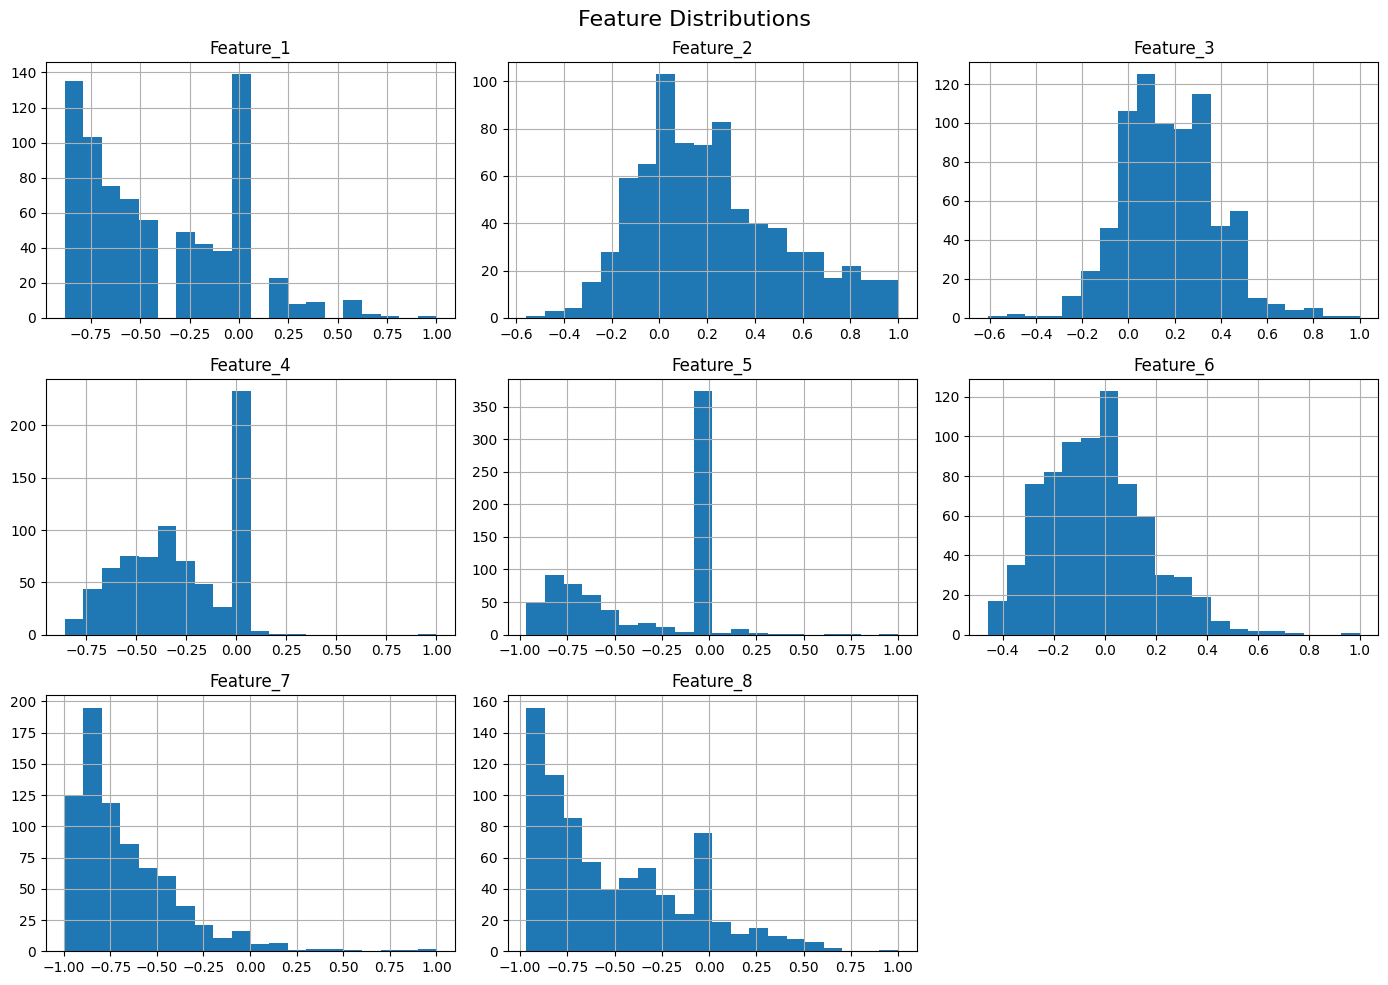

In [18]:
feature_columns = [
    "Feature_1",
    "Feature_2",
    "Feature_3",
    "Feature_4",
    "Feature_5",
    "Feature_6",
    "Feature_7",
    "Feature_8"
]

df[feature_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Feature Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Feature Distributions

The histograms show the distributions of the eight input features.
The supplied dataset contains numerical transformed features, so these
plots help visualize their ranges, concentration, and overall
distribution before model training.

In [19]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (759, 8)
y shape: (759,)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000


,Outcome
0,0
1,1
2,0
3,1
4,0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nPercentages:")
print(
    f"Training: {len(X_train) / len(df) * 100:.2f}%"
)
print(
    f"Validation: {len(X_val) / len(df) * 100:.2f}%"
)
print(
    f"Testing: {len(X_test) / len(df) * 100:.2f}%"
)

Training samples: 531
Validation samples: 114
Testing samples: 114

Percentages:
Training: 69.96%
Validation: 15.02%
Testing: 15.02%


### Train/Validation/Test Split

The dataset was divided into 70% training, 15% validation, and 15%
testing subsets using `random_state = 5996`. The same fixed split is
used for every PyTorch and TensorFlow model comparison. Stratification
was used to preserve the target-class proportions across the subsets.

In [21]:
X_train_processed = X_train.to_numpy(dtype=np.float32)
X_val_processed = X_val.to_numpy(dtype=np.float32)
X_test_processed = X_test.to_numpy(dtype=np.float32)

y_train_processed = y_train.to_numpy(dtype=np.float32)
y_val_processed = y_val.to_numpy(dtype=np.float32)
y_test_processed = y_test.to_numpy(dtype=np.float32)

print("X_train:", X_train_processed.shape)
print("X_val:", X_val_processed.shape)
print("X_test:", X_test_processed.shape)

X_train: (531, 8)
X_val: (114, 8)
X_test: (114, 8)


### Preprocessing

The supplied CSV already contains numerical transformed feature
values. Therefore, the feature values were retained as supplied rather
than applying an additional scaling transformation. The same processed
training, validation, and testing arrays are used for both PyTorch and
TensorFlow to ensure a fair framework comparison.

In [22]:
baseline_config = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.001,
    "epochs": 30
}

modified_config = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.003,
    "epochs": 30
}

print("Baseline Configuration")
print(baseline_config)

print("\nHP_ID 2 Modified Configuration")
print(modified_config)

Baseline Configuration
{'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 30}

HP_ID 2 Modified Configuration
{'hidden_layers': [64, 32], 'learning_rate': 0.003, 'epochs': 30}


In [23]:
import torch
import torch.nn as nn

X_train_t = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_val_t = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)

X_test_t = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_t = torch.tensor(
    y_train_processed,
    dtype=torch.float32
).reshape(-1, 1)

y_val_t = torch.tensor(
    y_val_processed,
    dtype=torch.float32
).reshape(-1, 1)

y_test_t = torch.tensor(
    y_test_processed,
    dtype=torch.float32
).reshape(-1, 1)

print("PyTorch tensor shapes:")
print("X_train:", X_train_t.shape)
print("y_train:", y_train_t.shape)
print("X_val:", X_val_t.shape)
print("y_val:", y_val_t.shape)
print("X_test:", X_test_t.shape)
print("y_test:", y_test_t.shape)

PyTorch tensor shapes:
X_train: torch.Size([531, 8])
y_train: torch.Size([531, 1])
X_val: torch.Size([114, 8])
y_val: torch.Size([114, 1])
X_test: torch.Size([114, 8])
y_test: torch.Size([114, 1])


In [24]:
class DiabetesNet(nn.Module):

    def __init__(self, input_size, hidden_layers):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(
                nn.Linear(previous_size, hidden_size)
            )
            layers.append(nn.ReLU())

            previous_size = hidden_size

        layers.append(
            nn.Linear(previous_size, 1)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [25]:
model = DiabetesNet(
    input_size=X_train_t.shape[1],
    hidden_layers=[64, 32]
)

print(model)

DiabetesNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [26]:
print("Dataset shape:", df.shape)
print(df.iloc[:, -1].unique())
print(df["Outcome"].value_counts())

Dataset shape: (759, 9)
[0 1]
Outcome
1    496
0    263
Name: count, dtype: int64


In [27]:
from sklearn.metrics import accuracy_score

def train_pytorch_model(
    hidden_layers,
    learning_rate,
    epochs,
    training_seed
):
    # Reproducibility for this training run
    random.seed(training_seed)
    np.random.seed(training_seed)
    torch.manual_seed(training_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(training_seed)

    # Build model
    model = DiabetesNet(
        input_size=X_train_t.shape[1],
        hidden_layers=hidden_layers
    )

    # Binary classification loss
    criterion = nn.BCEWithLogitsLoss()

    # Adam optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    # Training loop
    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        train_logits = model(X_train_t)

        train_loss = criterion(
            train_logits,
            y_train_t
        )

        train_loss.backward()
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()

        with torch.no_grad():

            val_logits = model(X_val_t)

            val_loss = criterion(
                val_logits,
                y_val_t
            )

        val_losses.append(val_loss.item())

    # Test evaluation
    model.eval()

    with torch.no_grad():

        test_logits = model(X_test_t)

        test_probabilities = torch.sigmoid(
            test_logits
        )

        test_predictions = (
            test_probabilities >= 0.5
        ).int().numpy().flatten()

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    return (
        model,
        test_accuracy,
        train_losses,
        val_losses
    )

In [28]:
pt_baseline_model, \
pt_baseline_acc, \
pt_baseline_train_loss, \
pt_baseline_val_loss = train_pytorch_model(
    hidden_layers=[64, 32],
    learning_rate=0.001,
    epochs=30,
    training_seed=SEED
)

print(
    f"PyTorch Baseline Test Accuracy: "
    f"{pt_baseline_acc:.4f}"
)

PyTorch Baseline Test Accuracy: 0.6491


In [29]:
pt_modified_model, \
pt_modified_acc, \
pt_modified_train_loss, \
pt_modified_val_loss = train_pytorch_model(
    hidden_layers=[64, 32],
    learning_rate=0.003,
    epochs=30,
    training_seed=SEED
)

print(
    f"PyTorch Modified Test Accuracy: "
    f"{pt_modified_acc:.4f}"
)

PyTorch Modified Test Accuracy: 0.7544


In [30]:
print("PyTorch Results")
print("------------------------------")
print(
    f"Baseline LR=0.001 : "
    f"{pt_baseline_acc:.4f}"
)

print(
    f"Modified LR=0.003 : "
    f"{pt_modified_acc:.4f}"
)

difference = pt_modified_acc - pt_baseline_acc

print(
    f"Accuracy Difference: "
    f"{difference:+.4f}"
)

PyTorch Results
------------------------------
Baseline LR=0.001 : 0.6491
Modified LR=0.003 : 0.7544
Accuracy Difference: +0.1053


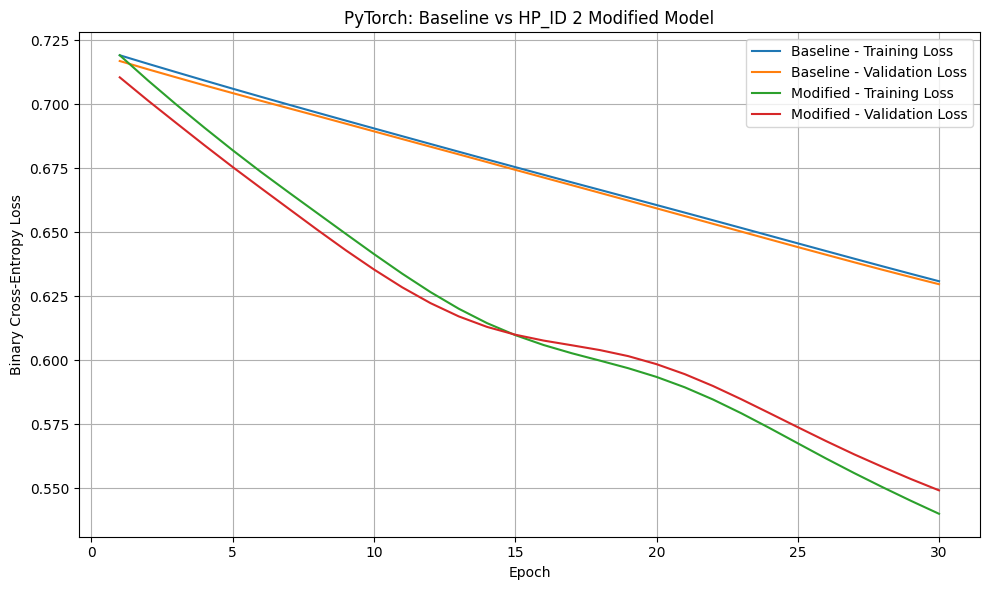

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 31),
    pt_baseline_train_loss,
    label="Baseline - Training Loss"
)

plt.plot(
    range(1, 31),
    pt_baseline_val_loss,
    label="Baseline - Validation Loss"
)

plt.plot(
    range(1, 31),
    pt_modified_train_loss,
    label="Modified - Training Loss"
)

plt.plot(
    range(1, 31),
    pt_modified_val_loss,
    label="Modified - Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "PyTorch: Baseline vs HP_ID 2 Modified Model"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### PyTorch Baseline vs Modified Model

The baseline and modified models use the same `[64, 32]` architecture
and are trained for 30 epochs. Because my assigned `HP_ID` is 2, the
only experimental change is the learning rate, which increases from
0.001 in the baseline to 0.003 in the modified model.

The training and validation loss curves are compared to determine
whether the higher learning rate improves convergence or introduces
less stable training behavior. The final interpretation is based on
both the loss curves and test accuracy.### PyTorch Results Interpretation

For the SEED = 5996 run, the baseline PyTorch model achieved a test
accuracy of 0.6491, while the HP_ID 2 modified model achieved a higher
test accuracy of 0.7544. The only change in the modified model was an
increase in learning rate from 0.001 to 0.003.

The modified model also produced lower final training and validation
losses of 0.5400 and 0.5491, respectively, compared with 0.6308 and
0.6297 for the baseline. Based on this run, the higher learning rate
allowed the model to converge faster within the fixed 30-epoch training
budget. There is no clear evidence of severe overfitting at the final
epoch because the modified training and validation losses remain close
to each other.

Overall, for this SEED run, the HP_ID 2 modified model performed better
than the baseline.


In [32]:
print("Final PyTorch Losses")
print("--------------------------------")

print(
    f"Baseline Training Loss: "
    f"{pt_baseline_train_loss[-1]:.4f}"
)

print(
    f"Baseline Validation Loss: "
    f"{pt_baseline_val_loss[-1]:.4f}"
)

print(
    f"Modified Training Loss: "
    f"{pt_modified_train_loss[-1]:.4f}"
)

print(
    f"Modified Validation Loss: "
    f"{pt_modified_val_loss[-1]:.4f}"
)

Final PyTorch Losses
--------------------------------
Baseline Training Loss: 0.6308
Baseline Validation Loss: 0.6297
Modified Training Loss: 0.5400
Modified Validation Loss: 0.5491


In [33]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [34]:
def build_tensorflow_model(hidden_layers):

    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(
            shape=(X_train_processed.shape[1],)
        )
    )

    for hidden_size in hidden_layers:

        model.add(
            tf.keras.layers.Dense(
                hidden_size,
                activation="relu"
            )
        )

    model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model

In [35]:
tf_test_model = build_tensorflow_model([64, 32])

tf_test_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
def train_tensorflow_model(
    hidden_layers,
    learning_rate,
    epochs,
    training_seed
):

    # Clear previous TensorFlow model state
    tf.keras.backend.clear_session()

    # Reproducibility
    random.seed(training_seed)
    np.random.seed(training_seed)
    tf.keras.utils.set_random_seed(training_seed)

    # Build model
    model = build_tensorflow_model(
        hidden_layers
    )

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    history = model.fit(
        X_train_processed,
        y_train_processed,
        validation_data=(
            X_val_processed,
            y_val_processed
        ),
        epochs=epochs,
        verbose=0,
        shuffle=False
    )

    # Test
    test_loss, test_accuracy = model.evaluate(
        X_test_processed,
        y_test_processed,
        verbose=0
    )

    return (
        model,
        test_accuracy,
        history.history["loss"],
        history.history["val_loss"]
    )

In [37]:
tf_baseline_model, \
tf_baseline_acc, \
tf_baseline_train_loss, \
tf_baseline_val_loss = train_tensorflow_model(
    hidden_layers=[64, 32],
    learning_rate=0.001,
    epochs=30,
    training_seed=SEED
)

print(
    f"TensorFlow Baseline Test Accuracy: "
    f"{tf_baseline_acc:.4f}"
)

TensorFlow Baseline Test Accuracy: 0.7281


In [38]:
tf_modified_model, \
tf_modified_acc, \
tf_modified_train_loss, \
tf_modified_val_loss = train_tensorflow_model(
    hidden_layers=[64, 32],
    learning_rate=0.003,
    epochs=30,
    training_seed=SEED
)

print(
    f"TensorFlow Modified Test Accuracy: "
    f"{tf_modified_acc:.4f}"
)

TensorFlow Modified Test Accuracy: 0.7368


In [39]:
print("TensorFlow Results")
print("--------------------------------")

print(
    f"Baseline LR=0.001 : "
    f"{tf_baseline_acc:.4f}"
)

print(
    f"Modified LR=0.003 : "
    f"{tf_modified_acc:.4f}"
)

tf_difference = (
    tf_modified_acc - tf_baseline_acc
)

print(
    f"Accuracy Difference: "
    f"{tf_difference:+.4f}"
)

TensorFlow Results
--------------------------------
Baseline LR=0.001 : 0.7281
Modified LR=0.003 : 0.7368
Accuracy Difference: +0.0088


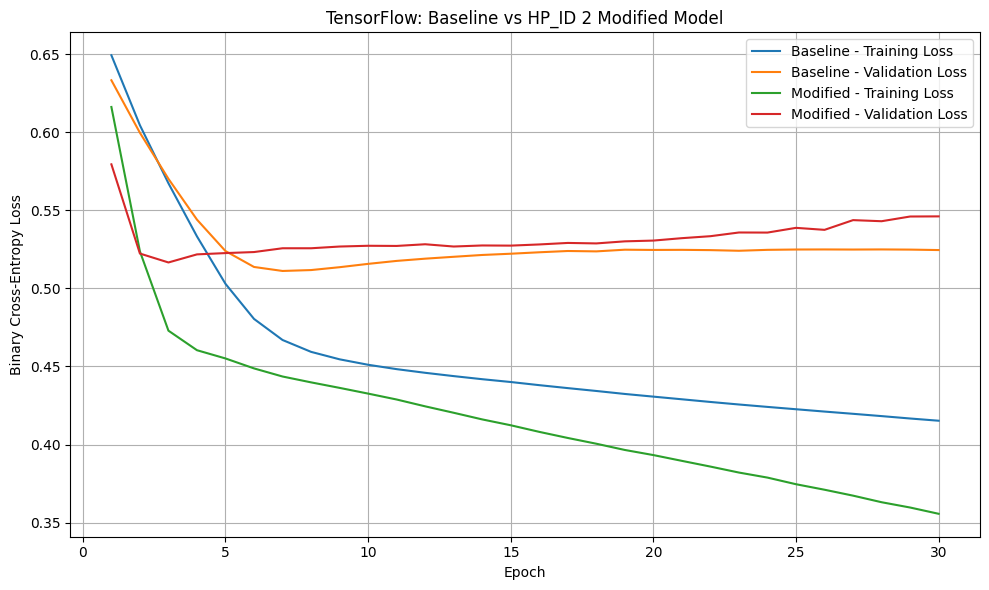

In [40]:
plt.figure(figsize=(10, 6))

epochs_range = range(1, 31)

plt.plot(
    epochs_range,
    tf_baseline_train_loss,
    label="Baseline - Training Loss"
)

plt.plot(
    epochs_range,
    tf_baseline_val_loss,
    label="Baseline - Validation Loss"
)

plt.plot(
    epochs_range,
    tf_modified_train_loss,
    label="Modified - Training Loss"
)

plt.plot(
    epochs_range,
    tf_modified_val_loss,
    label="Modified - Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "TensorFlow: Baseline vs HP_ID 2 Modified Model"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [41]:
print("Final TensorFlow Losses")
print("--------------------------------")

print(
    f"Baseline Training Loss: "
    f"{tf_baseline_train_loss[-1]:.4f}"
)

print(
    f"Baseline Validation Loss: "
    f"{tf_baseline_val_loss[-1]:.4f}"
)

print(
    f"Modified Training Loss: "
    f"{tf_modified_train_loss[-1]:.4f}"
)

print(
    f"Modified Validation Loss: "
    f"{tf_modified_val_loss[-1]:.4f}"
)

Final TensorFlow Losses
--------------------------------
Baseline Training Loss: 0.4153
Baseline Validation Loss: 0.5246
Modified Training Loss: 0.3556
Modified Validation Loss: 0.5461


In [42]:
training_seeds = [
    SEED,
    SEED + 1,
    SEED + 2
]

print("Training seeds:", training_seeds)

Training seeds: [5996, 5997, 5998]


In [43]:
pt_baseline_results = []
pt_modified_results = []

for training_seed in training_seeds:

    # Baseline
    _, baseline_acc, _, _ = train_pytorch_model(
        hidden_layers=[64, 32],
        learning_rate=0.001,
        epochs=30,
        training_seed=training_seed
    )

    pt_baseline_results.append(
        baseline_acc
    )

    # Modified
    _, modified_acc, _, _ = train_pytorch_model(
        hidden_layers=[64, 32],
        learning_rate=0.003,
        epochs=30,
        training_seed=training_seed
    )

    pt_modified_results.append(
        modified_acc
    )

    print(
        f"Seed {training_seed}: "
        f"Baseline={baseline_acc:.4f}, "
        f"Modified={modified_acc:.4f}"
    )

Seed 5996: Baseline=0.6491, Modified=0.7544
Seed 5997: Baseline=0.6491, Modified=0.7544
Seed 5998: Baseline=0.6491, Modified=0.7456


In [44]:
pt_baseline_mean = np.mean(
    pt_baseline_results
)

pt_baseline_std = np.std(
    pt_baseline_results
)

pt_modified_mean = np.mean(
    pt_modified_results
)

pt_modified_std = np.std(
    pt_modified_results
)

print("\nPyTorch Three-Seed Results")
print("--------------------------------")

print(
    f"Baseline: "
    f"{pt_baseline_mean:.4f} ± "
    f"{pt_baseline_std:.4f}"
)

print(
    f"Modified: "
    f"{pt_modified_mean:.4f} ± "
    f"{pt_modified_std:.4f}"
)


PyTorch Three-Seed Results
--------------------------------
Baseline: 0.6491 ± 0.0000
Modified: 0.7515 ± 0.0041


In [45]:
tf_baseline_results = []
tf_modified_results = []

for training_seed in training_seeds:

    # Baseline
    _, baseline_acc, _, _ = train_tensorflow_model(
        hidden_layers=[64, 32],
        learning_rate=0.001,
        epochs=30,
        training_seed=training_seed
    )

    tf_baseline_results.append(
        baseline_acc
    )

    # Modified
    _, modified_acc, _, _ = train_tensorflow_model(
        hidden_layers=[64, 32],
        learning_rate=0.003,
        epochs=30,
        training_seed=training_seed
    )

    tf_modified_results.append(
        modified_acc
    )

    print(
        f"Seed {training_seed}: "
        f"Baseline={baseline_acc:.4f}, "
        f"Modified={modified_acc:.4f}"
    )

Seed 5996: Baseline=0.7281, Modified=0.7368
Seed 5997: Baseline=0.7281, Modified=0.7193
Seed 5998: Baseline=0.7456, Modified=0.7281


In [46]:
tf_baseline_mean = np.mean(
    tf_baseline_results
)

tf_baseline_std = np.std(
    tf_baseline_results
)

tf_modified_mean = np.mean(
    tf_modified_results
)

tf_modified_std = np.std(
    tf_modified_results
)

print("\nTensorFlow Three-Seed Results")
print("--------------------------------")

print(
    f"Baseline: "
    f"{tf_baseline_mean:.4f} ± "
    f"{tf_baseline_std:.4f}"
)

print(
    f"Modified: "
    f"{tf_modified_mean:.4f} ± "
    f"{tf_modified_std:.4f}"
)


TensorFlow Three-Seed Results
--------------------------------
Baseline: 0.7339 ± 0.0083
Modified: 0.7281 ± 0.0072


In [47]:
results_df = pd.DataFrame({
    "Framework": [
        "PyTorch",
        "PyTorch",
        "TensorFlow",
        "TensorFlow"
    ],

    "Model": [
        "Baseline",
        "HP_ID 2 Modified",
        "Baseline",
        "HP_ID 2 Modified"
    ],

    "Hidden Layers": [
        "[64, 32]",
        "[64, 32]",
        "[64, 32]",
        "[64, 32]"
    ],

    "Learning Rate": [
        0.001,
        0.003,
        0.001,
        0.003
    ],

    "Epochs": [
        30,
        30,
        30,
        30
    ],

    "Mean Test Accuracy": [
        pt_baseline_mean,
        pt_modified_mean,
        tf_baseline_mean,
        tf_modified_mean
    ],

    "Std Test Accuracy": [
        pt_baseline_std,
        pt_modified_std,
        tf_baseline_std,
        tf_modified_std
    ]
})

display(results_df)

,Framework,Model,Hidden Layers,Learning Rate,Epochs,Mean Test Accuracy,Std Test Accuracy
0,PyTorch,Baseline,"[64, 32]",0.001,30,0.649123,0.000000
1,PyTorch,HP_ID 2 Modified,"[64, 32]",0.003,30,0.751462,0.004135
2,TensorFlow,Baseline,"[64, 32]",0.001,30,0.733918,0.008270
3,TensorFlow,HP_ID 2 Modified,"[64, 32]",0.003,30,0.728070,0.007162


## Neural Network Results and Conclusion

My assigned HP_ID is 2, corresponding to the learning-rate-high
configuration. Therefore, the baseline and modified models both use
hidden layers [64, 32] and train for 30 epochs, while the learning
rate changes from 0.001 to 0.003.

Across the three training seeds 5996, 5997, and 5998, the PyTorch
baseline achieved a mean test accuracy of 0.6491 with a standard
deviation of 0.0000. The modified PyTorch model achieved a substantially
higher mean accuracy of 0.7515 with a standard deviation of 0.0041.
Therefore, increasing the learning rate improved PyTorch performance
within the fixed 30-epoch training budget.

For TensorFlow, the baseline achieved a mean test accuracy of 0.7339
with a standard deviation of 0.0083, while the modified model achieved
0.7281 with a standard deviation of 0.0072. Therefore, the higher
learning rate did not improve TensorFlow test accuracy on average.

Overall, the effect of the higher learning rate was framework-dependent.
It substantially improved the PyTorch model but produced slightly lower
mean test accuracy in TensorFlow. This demonstrates that the same
hyperparameter change can affect optimization behavior differently
across implementations.